In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import GridSpec
import matplotlib.gridspec as gridspec
import glob
import pandas as pd
import math
import random
import scipy
from scipy.stats import mannwhitneyu
from collections import defaultdict

import seaborn as sns

plt.style.use('styleNB.mplstyle')


# Function for subsampling 
def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
        d_ = d_.copy().sort_values('frame')
        interval_frames = d_.frame.values[::frame_step]
        sampled = d_[d_['frame'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    df_out['interval'] = df_out['frame']

    return df_out


# Figure 3 - EL4 cell line data (migration in 3D collagen)

## Load in data

In [9]:
# LOAD in the .csv data file of cell tracks
df = pd.read_csv('../../data/processed_3D_tracking/20250429_compiled_EL-4_TMEM154_KO_lines.csv')

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 20:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Filter: skip low-displacement tracks (still only 2D for this filter)
    total_movement = np.sum(np.linalg.norm(np.diff(positions[:, :2], axis=0), axis=1))
    if total_movement < 15:
        continue
    
    # Store filtered 3D track 
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'cell': g[5],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1]
        })
    ], ignore_index=True)


df_filtered_tracks.celltype.unique()

array(['EL4 KO12', 'EL4 KO12 + Galvanin-eGFP-HA', 'EL4 WT',
       'EL4 WT + Galvanin-eGFP-HA'], dtype=object)

In [10]:
# for supplemental, keep simple and just consider WT and KO
df_filtered_tracks = df_filtered_tracks[df_filtered_tracks.celltype != 'EL4 WT + Galvanin-eGFP-HA']
df_filtered_tracks = df_filtered_tracks[df_filtered_tracks.celltype != 'EL4 KO12 + Galvanin-eGFP-HA']

color_dict = {'EL4 WT': '#B8BABC',
 'EL4 KO12': (1.0, 0.4980392156862745, 0.054901960784313725)}

In [11]:
df_filtered_tracks.head()

,celltype,E_V_cm,date,trial,user,cell,frame,x,y
0,EL4 KO12,0,20250315,0,HK,5,0.0,474.885894,626.245151
1,EL4 KO12,0,20250315,0,HK,5,1.0,476.475097,625.803959
2,EL4 KO12,0,20250315,0,HK,5,2.0,478.922463,625.859465
3,EL4 KO12,0,20250315,0,HK,5,3.0,478.028059,625.290090
4,EL4 KO12,0,20250315,0,HK,5,4.0,477.388413,624.353928


## Cell trajectories

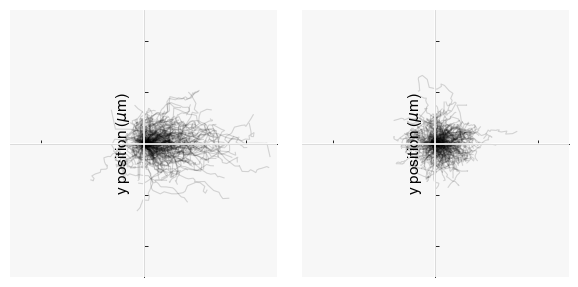

In [12]:
import matplotlib.pyplot as plt

# Create a 2x1 subplot for the two cell types under 3 V/cm
f, ax = plt.subplots(1, 2, figsize=(6, 3))  # Adjust figure size as needed

# Updated mapping since we only care about 3 V/cm
dict_ax = {'EL4 WT': 0, 'EL4 KO12': 1}

# Loop through only 3 V/cm data
for g, d in df_filtered_tracks.groupby(['celltype', 'E_V_cm']):
    celltype, E_V_cm = g
    if E_V_cm != 3:
        continue  # Skip if not 3 V/cm

    trajectories = []
    count_cell = 0

    for i, d_ in d.groupby(['cell', 'trial', 'date', 'user']):
        if count_cell > 200:
            continue

        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax_ = ax[dict_ax[celltype]]
        ax_.plot(x_rel, y_rel, color='black', alpha=0.15, lw=0.8, zorder=10)

        count_cell += 1

    ax_ = ax[dict_ax[celltype]]

    # Draw white zero lines
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Axis styling
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.set_xlim(-130, 130)
    ax_.set_ylim(-130, 130)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')
    ax_.set_facecolor('#f7f7f7')
    ax_.set_xlabel(r'x position ($\mu$m)')
    ax_.set_ylabel(r'y position ($\mu$m)')

# Tidy labels and ticks
for i in range(2):
    ax_ = ax[i]
    ax_.set_xlabel('')
    ax_.tick_params(labelbottom=False)
    ax_.tick_params(labelleft=False)


    # if i < 1:  # Only bottom subplot keeps x-labels
    #     ax_.set_xlabel('')
    #     ax_.tick_params(labelbottom=False)
    # if i > 0:  # Only leftmost keeps y-labels
    #     ax_.set_ylabel('')
    #     ax_.tick_params(labelleft=False)

    ax_.set_xticklabels([])
    ax_.set_yticklabels([])
    ax_.tick_params(length=3)

plt.tight_layout()
# f.savefig('filtered_tracks_3Vcm.pdf', bbox_inches='tight')

('EL4 KO12', 0)
('EL4 KO12', 1)
('EL4 KO12', 3)
('EL4 WT', 0)
('EL4 WT', 1)
('EL4 WT', 3)


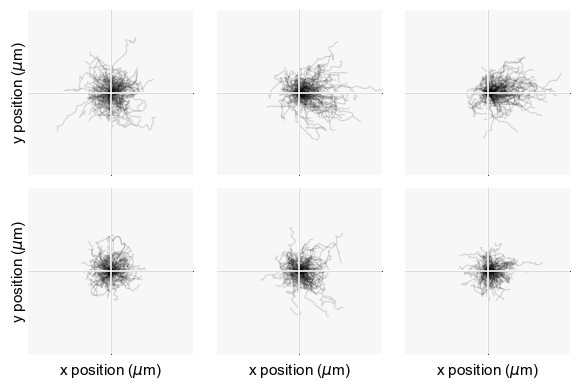

In [13]:
f, ax = plt.subplots(2, 3, figsize=(6, 4))
EF_dict = {0: 0, 1: 1, 3: 2}
# dict_ax = {'Galvanin_WT': 0, 'Galvanin_KO': 1}


for g, d in df_filtered_tracks.groupby(['celltype', 'E_V_cm']):
    print(g)
    trajectories = []
    count_cell = 0
    for i, d_ in d.groupby(['cell', 'trial', 'date', 'user']):
        if len(d_) < 5:
            continue
        if count_cell > 126:
            continue


        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax_ = ax[dict_ax[g[0]], EF_dict[g[1]]]
        ax_.plot(x_rel, y_rel, color='black', alpha=0.15, lw=0.8, zorder=10)

        # Optional: mark final point faintly
        #ax_.scatter(x_rel[-1], y_rel[-1], s=2, color='black', alpha=0.1, zorder=5)

        count_cell += 1

    ax_ = ax[dict_ax[g[0]], EF_dict[g[1]]]

    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    ax_.set_xlim(-120, 120)
    ax_.set_ylim(-120, 120)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    ax_.set_xlabel(r'x position ($\mu$m)')
    ax_.set_ylabel(r'y position ($\mu$m)')

n_rows, n_cols = ax.shape

for r in range(n_rows):
    for c in range(n_cols):
        ax_ = ax[r, c]

        # Hide x labels if not in bottom row
        if r < n_rows - 1:
            ax_.set_xlabel('')
            ax_.tick_params(labelbottom=False)

        # Hide y labels if not in leftmost column
        if c > 0:
            ax_.set_ylabel('')
            ax_.tick_params(labelleft=False)

n_rows, n_cols = ax.shape

for r in range(n_rows):
    for c in range(n_cols):
        ax_ = ax[r, c]

        # Keep axis labels only on outer left and bottom
        if r < n_rows - 1:
            ax_.set_xlabel('')
        if c > 0:
            ax_.set_ylabel('')

        # Remove all tick labels
        ax_.set_xticklabels([])
        ax_.set_yticklabels([])

        # Optional: reduce tick mark length
        ax_.tick_params(length=0)
            
plt.tight_layout()
# f.savefig('../../figures/20250626_EL4_tracks.pdf', bbox_inches='tight')

## Compass autocorrelation

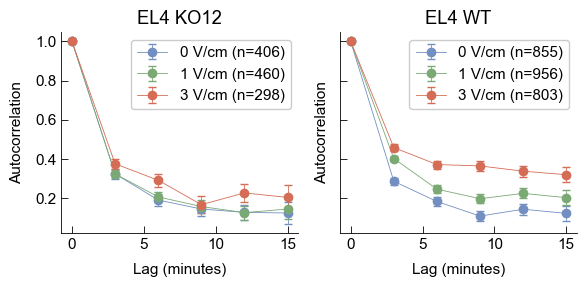

In [16]:
# Step 1: Define interval (number of frames between points)
interval = 3 # use same as HL-60

# Step 2: subsample
df_intervals = parse_trajectories(df_filtered_tracks, frame_step=interval)
    
def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr
        
autocorr_list = []

for g, d in df_intervals.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * interval,  # actual lag in frames
        'autocorr': acf
    }))
    
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()


celltypes = df_avg_autocorr.celltype.unique()
fig, axes = plt.subplots(1, len(celltypes), figsize=(3*len(celltypes),3), sharey=True)

if len(celltypes) == 1:
    axes = [axes]

for ax, celltype in zip(axes, celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype==celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]  # same across lags if consistent
        ax.errorbar(
            d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})", capsize=3, marker='o'
        )
    ax.set_title(celltype)
    ax.set_xlabel('Lag (minutes)')
    ax.set_ylabel('Autocorrelation')
    ax.legend()
plt.tight_layout()

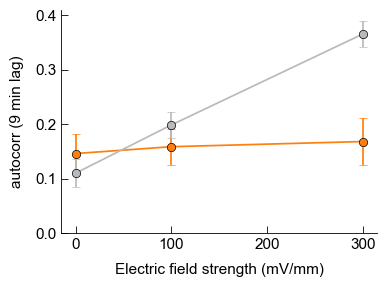

   E_V_cm  statistic   p_value    metric
0       0   178786.5  0.387482  autocorr
1       1   209660.0  0.156104  autocorr
2       3    98737.0  0.000008  autocorr


In [19]:
lag_to_plot = 9 
df_plot = df_avg_autocorr[df_avg_autocorr.lag == lag_to_plot]

fig, axs = plt.subplots(1, 1, figsize=(4, 3), sharex=False)

ax_bottom = axs
for celltype, d in df_plot.groupby('celltype'):
    d_sorted = d.sort_values('E_V_cm')
    ax_bottom.errorbar(
        x=d_sorted.E_V_cm.values * 100,
        y=d_sorted.mean_autocorr,
        yerr=d_sorted.sem_autocorr,
        label=f"{celltype} (n={d_sorted.num_trajectories.values[0]})",
        marker='o',
        markersize=6,
        lw=1.25,
        capsize=3,
        zorder=10,
        color=color_dict[celltype],
        markeredgecolor='k',
        markeredgewidth=0.5
    )

# ax_bottom.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=0)
ax_bottom.set_xlabel('Electric field strength (mV/mm)')
ax_bottom.set_ylabel('autocorr (9 min lag)')
ax_bottom.set_ylim(0,0.41)

plt.tight_layout()
plt.show()

# fig.savefig('../../figures/Figure3_EL4_compass_.pdf', bbox_inches='tight')


##################### 
# Stats

# Define cell types
celltypes = df_intervals.celltype.unique() 

def perform_mannwhitney_autocorr(df):
    df_lag = df[df['lag'] == 9]
    results = []
    for ev in sorted(df_lag['E_V_cm'].unique()):
        subset = df_lag[df_lag['E_V_cm'] == ev]
        group1 = subset[subset['celltype'] == celltypes[0]]['autocorr'].dropna()
        group2 = subset[subset['celltype'] == celltypes[1]]['autocorr'].dropna()
        if len(group1) > 0 and len(group2) > 0:
            stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
            results.append({'E_V_cm': ev, 'statistic': stat, 'p_value': p, 'metric': 'autocorr'})
    return pd.DataFrame(results)

# Run test
df_stats_autocorr = perform_mannwhitney_autocorr(df_autocorr)
print(df_stats_autocorr)


In [8]:
# Create a new global unique cell ID per group
df_intervals['cell_global'] = (
    df_intervals['date'].astype(str) + '_' +
    df_intervals['trial'].astype(str) + '_' +
    df_intervals['user'].astype(str) + '_' +
    df_intervals['cell'].astype(str)
)

# Containers for summary
summary_stats = []

# Group by condition to compute cell-level and sample-level stats
grouped = df_intervals.groupby(['celltype', 'E_V_cm'])

for (celltype, E_V_cm), df_group in grouped:
    # Count unique samples (trial/date/user) and cells
    samples = df_group.groupby(['date', 'trial', 'user']).ngroups
    unique_cells = df_group['cell_global'].nunique()

    summary_stats.append({
        'celltype': celltype,
        'E_V_cm': E_V_cm,
        'n_samples': samples,
        'n_cells': unique_cells
    })

# Convert to DataFrame
df_summary_stats = pd.DataFrame(summary_stats)

# Optional: sort for clean display
df_summary_stats = df_summary_stats.sort_values(['celltype', 'E_V_cm'])

df_summary_stats

,celltype,E_V_cm,n_samples,n_cells
0,EL4 KO12,0,6,406
1,EL4 KO12,1,6,460
2,EL4 KO12,3,6,298
3,EL4 WT,0,12,855
4,EL4 WT,1,12,956
5,EL4 WT,3,12,803
